# Import

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf
from tensorflow.keras import layers
import os
import re, string
import pathlib  # 객체지향 방식으로 파일 경로를 다룸
import urllib.request # url을 통해 파일 다운로드 기능 제공
import tarfile
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\human-23\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Data

## READ CSV

In [13]:
df = pd.read_csv('.\dataset\PubMed.csv')

## 관련 Column 병합
+ 원하는 자료를 병합하여 1개 column을 검색에 사용할 예정임.

In [14]:
# Title이나 abstractText가 비어있는 경우(NaN) 빈 문자열로 채운 후 병합합니다.
df['Content'] = df['Title'].fillna('') + ": " + df['abstractText'].fillna('')
df['Content'].head()

0    Expression of p53 and coexistence of HPV in pr...
1    Vitamin D status in pregnant Indian women acro...
2    [Identification of a functionally important di...
3    Multilayer capsules: a promising microencapsul...
4    Nanohydrogel with N,N'-bis(acryloyl)cystine cr...
Name: Content, dtype: object

## Punctuation 제거

In [15]:
# 1. Define the function 
def custom_standardization(input_data):
    lowercase = tf.strings.lower(input_data)
    return tf.strings.regex_replace(lowercase, f'[{re.escape(string.punctuation)}]', '')


## Stop word 제거

In [16]:

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    if pd.isna(text): return ""
    words = text.split()
    filtered_words = [w for w in words if w.lower() not in stop_words]
    return " ".join(filtered_words)

df['Content'] = df['Content'].apply(remove_stopwords)

## Output 준비

[A] Anatomy: Body parts, tissues, cells.
[B] Organisms: Animals, plants, viruses, bacteria.
[C] Diseases: Pathological conditions, symptoms, injuries.
[D] Chemicals and Drugs: Pharmacological agents, compounds.
[E] Analytical, Diagnostic and Therapeutic Techniques, and Equipment: Techniques, procedures, diagnostic tools.
[F] Psychiatry and Psychology: Mental processes, behaviors.
[G] Phenomena and Processes: Biological/physical processes (e.g., metabolism, genetics).
[H] Disciplines and Occupations: Fields of study, professions.
[I] Anthropology, Education, Sociology, and Social Phenomena: Social aspects of health.
[J] Technology, Industry, and Agriculture: Products, machinery, agricultural techniques.
[K] Humanities: History, ethics, philosophy.
[L] Information Science: Library science, communication, computer science.
[M] Named Groups: Demographic groups, populations.
[N] Health Care: Services, policy, economics, management.
[V] Publication Characteristics: Types of articles (e.g., reviews, clinical trials).
[Z] Geographicals: Countries, regions, locations.

In [17]:
target_cols = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'L', 'M', 'N', 'Z']
num_classes = len(target_cols)
y = df[target_cols].values.astype('float32')
print(f"총 {num_classes}개의 카테고리를 분류합니다.")

총 14개의 카테고리를 분류합니다.


## Train Test Split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    df['Content'], 
    y, 
    test_size=0.2, 
    random_state=42
)

X_train_arr = np.array(X_train, dtype=object)
X_test_arr = np.array(X_test, dtype=object)
y_train_arr = np.array(y_train).astype('float32')
y_test_arr = np.array(y_test).astype('float32')

print(f"학습 데이터 개수: {len(X_train)}")
print(f"테스트 데이터 개수: {len(X_test)}")

학습 데이터 개수: 40000
테스트 데이터 개수: 10000


## Tokenization

### TextVectorization

In [ ]:
vectorize_layer = tf.keras.layers.TextVectorization(
    standardize=custom_standardization,
    max_tokens=10000,
    output_mode='int' ,
    output_sequence_length = 250
)

vectorize_layer.adapt(X_train)

# Model

## Embedding Layer 

In [20]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(), dtype=tf.string), 

    # BiLTMS is superior to TF-IDF
    # Lower number of layers shows superior result
    # Confirm effect of batch normalization
    # confirm effect of dropout

    # 1. 원문을 숫자 시퀀스로 변환 (250단어)
    vectorize_layer, 
    # 2. 단어의 뉘앙스를 학습하는 고차원 지도 (128차원)
    layers.Embedding(input_dim=10000, output_dim=128),
    # 3. 앞뒤 맥락을 모두 읽는 엔진
    layers.Bidirectional(layers.LSTM(64, return_sequences=True)),
    # 4. 전체 요약 (평균값 추출)
    layers.GlobalAveragePooling1D(),
    
    # 5. 최종 분류를 위한 추론 레이어
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),   
    
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),

    # 출력층 (14개 카테고리)
    # Softmax is superior to sigmoid 
    layers.Dense(num_classes, activation='sigmoid')
])

## Dense (Hidden) Layers & BiLTSM

## Output Layer

In [ ]:
model.compile(
    optimizer='adam', 
    loss='binary_crossentropy', 
    metrics=['binary_accuracy']
)


early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,          # 3번의 epoch 동안 기다림
    restore_best_weights=True # 가장 좋았던 상태의 가중치로 복구
)

#Early stopping is necessary. 

history = model.fit(
    X_train_arr, y_train_arr,
    epochs=20,                    # Epoch를 넉넉히 잡고 EarlyStopping에 맡깁니다.
    validation_data=(X_test_arr, y_test_arr),
    batch_size=128,
    callbacks=[early_stopping]    # 3. 조기 종료 적용
)

# Dont forget to save models (use Keras)
# Then load Models (use Keras)

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 79s 60ms/step - binary_accuracy: 0.8226 - loss: 0.4017 - val_binary_accuracy: 0.8568 - val_loss: 0.3370
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 66s 53ms/step - binary_accuracy: 0.8545 - loss: 0.3415 - val_binary_accuracy: 0.8583 - val_loss: 0.3297
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 65s 52ms/step - binary_accuracy: 0.8637 - loss: 0.3226 - val_binary_accuracy: 0.8615 - val_loss: 0.3235
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 64s 51ms/step - binary_accuracy: 0.8693 - loss: 0.3086 - val_binary_accuracy: 0.8620 - val_loss: 0.3268
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 66s 53ms/step - binary_accuracy: 0.8747 - loss: 0.2974 - val_binary_accuracy: 0.8615 - val_loss: 0.3296
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 69s 55ms/step - binary_accuracy: 0.8782 - loss: 0.2881 - val_binary_accuracy: 0.8603 - val_loss: 0.3333


# Defining "Relevance"

## Option A: The "Explainable" Route (Recommended)

Your model predicts the 16 broad categories. Since you are looking for Pulmonary Diseases, you look at the output for Diseases [C].Logic: If the model's confidence for Diseases [C] is $> 0.8$, you mark it as "Potentially Relevant."Why this is good: It tells you why a paper was picked.

## Option B: The "End-to-End" Route

You create a new "Ground Truth" label in your CSV.

Logic: Any row that has the specific MeSH code for Respiratory Diseases (usually starting with C08) is labeled 1 (Relevant), and everything else is 0 (Not Relevant).

The Model: Your output layer becomes just 1 node (Relevant vs. Not Relevant).

# Visualization

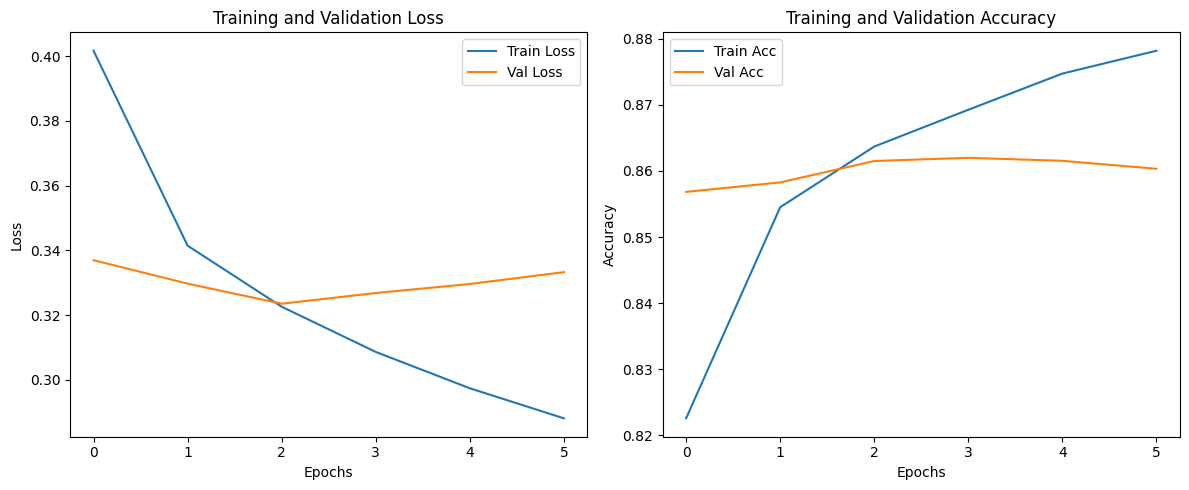

In [22]:
plt.figure(figsize=(12, 5))

# 1. Loss 그래프 (Overfitting 확인용)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# 2. Accuracy 그래프 (성능 확인용)
plt.subplot(1, 2, 2)
acc_key = 'binary_accuracy'
plt.plot(history.history[acc_key], label='Train Acc')
plt.plot(history.history[f'val_{acc_key}'], label='Val Acc')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

1. save model
2. get y_pred
3. reverse scale
4. visualize pred vs actual val (both written and graph)
5. DataFrame으로 예측값과 실제값 비교
6. 예측값 역변환
7. DBMS 저장
  Date 형식을 'YYYY-MM-DD'로 변환
  데이터 타입 정의
  데이터 저장
  DB 연결 및 쿼리 실행
  결과값 가져오기
  연결 닫기